In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [9]:
df = pd.read_csv('../data/raw/demographic_health_data.csv')
df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


# Seleccionar variable objetivo y features 

In [10]:
# Variable a predecir: prevalencia de diabetes
target = 'diabetes_prevalence'

# Variables predictoras 
features = [
    'PCTPOVALL_2018',  # % de pobreza
    'Obesity_prevalence',  # % obesidad
    'Heart disease_prevalence',  # % enfermedades cardíacas
    'Unemployment_rate_2018',  # % desempleo
    'Percent of adults with less than a high school diploma 2014-18',  # % sin secundaria
]
data = df[[target] + features].copy()
data = data.dropna()

print(f"Variable a predecir: {target}")
print(f"\nVariables predictoras ({len(features)}):")
for i, f in enumerate(features, 1):
    print(f"  {i}. {f}")

Variable a predecir: diabetes_prevalence

Variables predictoras (5):
  1. PCTPOVALL_2018
  2. Obesity_prevalence
  3. Heart disease_prevalence
  4. Unemployment_rate_2018
  5. Percent of adults with less than a high school diploma 2014-18


# Crear dataset de trabajo

In [11]:
data = df[[target] + features].copy()
data = data.dropna()  # Eliminar filas con datos faltantes
print(f"\n Dataset limpio: {len(data)} condados")


 Dataset limpio: 3140 condados


# Estadísticas básicas

In [12]:
print(f"\nEstadísticas de Diabetes:")
print(f"  Promedio: {data[target].mean():.2f}%")
print(f"  Mínimo: {data[target].min():.2f}%")
print(f"  Máximo: {data[target].max():.2f}%")


Estadísticas de Diabetes:
  Promedio: 13.07%
  Mínimo: 6.10%
  Máximo: 25.60%


# Gráfico de distribución

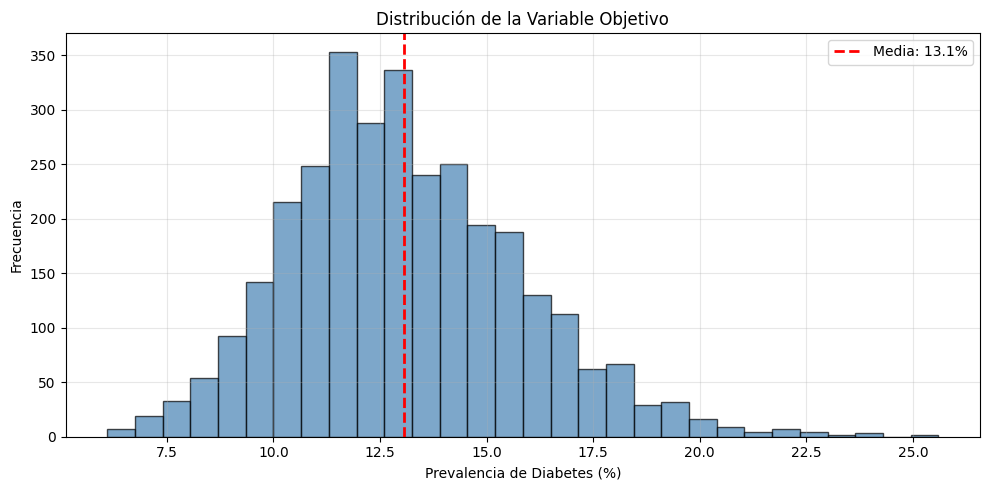

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(data[target], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(data[target].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Media: {data[target].mean():.1f}%')
plt.xlabel('Prevalencia de Diabetes (%)')
plt.ylabel('Frecuencia')
plt.title('Distribución de la Variable Objetivo')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show() 
plt.close()


# Matriz de correlación

In [ ]:
print(f"\n Correlaciones con {target}:")
correlaciones = data.corr()[target].drop(target).sort_values(ascending=False)
for var, corr in correlaciones.items():
    print(f"   • {var[:45]:45s}: {corr:6.3f}")


 Correlaciones con diabetes_prevalence:
   • Heart disease_prevalence                     :  0.831
   • PCTPOVALL_2018                               :  0.735
   • Obesity_prevalence                           :  0.699
   • Percent of adults with less than a high schoo:  0.699
   • Unemployment_rate_2018                       :  0.491


# PREPARACIÓN DE MÚLTIPLES VERSIONES DEL DATASET

In [15]:
# Separar X e y
X = data[features]
y = data[target]

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nDivisión realizada:")
print(f"   Train: {len(X_train)} muestras")
print(f"   Test: {len(X_test)} muestras")


División realizada:
   Train: 2512 muestras
   Test: 628 muestras


## Función para detectar outliers 

In [16]:
def detectar_outliers(df):
    """Detecta outliers usando el método IQR"""
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    outliers_mask = ~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)
    return outliers_mask

# Crear las 6 versiones del dataset

In [19]:
# CON outliers (original)
X_train_CON_outliers = X_train.copy()

# CON outliers + Normalización (MinMaxScaler)
scaler_norm = MinMaxScaler()
X_train_CON_outliers_norm = pd.DataFrame(
    scaler_norm.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

# CON outliers + Estandarización (StandardScaler)
scaler_scal = StandardScaler()
X_train_CON_outliers_scal = pd.DataFrame(
    scaler_scal.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

In [20]:
# SIN outliers
outliers_mask = detectar_outliers(X_train)
X_train_SIN_outliers = X_train[outliers_mask].copy()
y_train_SIN_outliers = y_train[outliers_mask].copy()

# 5. SIN outliers + Normalización
scaler_norm_sin = MinMaxScaler()
X_train_SIN_outliers_norm = pd.DataFrame(
    scaler_norm_sin.fit_transform(X_train_SIN_outliers),
    columns=X_train_SIN_outliers.columns,
    index=X_train_SIN_outliers.index
)

# 6. SIN outliers + Estandarización
scaler_scal_sin = StandardScaler()
X_train_SIN_outliers_scal = pd.DataFrame(
    scaler_scal_sin.fit_transform(X_train_SIN_outliers),
    columns=X_train_SIN_outliers.columns,
    index=X_train_SIN_outliers.index
)

print(f"    1. CON outliers (original): {X_train_CON_outliers.shape}")
print(f"    2. CON outliers + normalización: {X_train_CON_outliers_norm.shape}")
print(f"    3. CON outliers + estandarización: {X_train_CON_outliers_scal.shape}")
print(f"    4. SIN outliers: {X_train_SIN_outliers.shape}")
print(f"    5. SIN outliers + normalización: {X_train_SIN_outliers_norm.shape}")
print(f"    6. SIN outliers + estandarización: {X_train_SIN_outliers_scal.shape}")


    1. CON outliers (original): (2512, 5)
    2. CON outliers + normalización: (2512, 5)
    3. CON outliers + estandarización: (2512, 5)
    4. SIN outliers: (2288, 5)
    5. SIN outliers + normalización: (2288, 5)
    6. SIN outliers + estandarización: (2288, 5)


# SELECCIÓN DEL MEJOR DATASET 

In [21]:
# Lista de datasets y sus nombres
datasets = [
    (X_train_CON_outliers, y_train, "CON outliers"),
    (X_train_CON_outliers_norm, y_train, "CON outliers + normalización"),
    (X_train_CON_outliers_scal, y_train, "CON outliers + estandarización"),
    (X_train_SIN_outliers, y_train_SIN_outliers, "SIN outliers"),
    (X_train_SIN_outliers_norm, y_train_SIN_outliers, "SIN outliers + normalización"),
    (X_train_SIN_outliers_scal, y_train_SIN_outliers, "SIN outliers + estandarización")
]

In [24]:
# Probar cada dataset con Regresión Lineal
print("\n Probando cada dataset con Regresión Lineal...")
models = []
metrics = []

for X_dataset, y_dataset, nombre in datasets:
    model = LinearRegression()
    model.fit(X_dataset, y_dataset)
    y_pred = model.predict(X_dataset)
    metric = r2_score(y_dataset, y_pred)
    metrics.append(metric)
    models.append(model)
    print(f"    {nombre:35s} → R² = {metric:.4f}")

# Encontrar el mejor
best_metric = max(metrics)
best_index = metrics.index(best_metric)
best_dataset_name = datasets[best_index][2]
best_X = datasets[best_index][0]
best_y = datasets[best_index][1]

print(f"\n MEJOR DATASET: {best_dataset_name}")
print(f" R² Score: {best_metric:.4f}")


 Probando cada dataset con Regresión Lineal...
    CON outliers                        → R² = 0.8638
    CON outliers + normalización        → R² = 0.8638
    CON outliers + estandarización      → R² = 0.8638
    SIN outliers                        → R² = 0.8499
    SIN outliers + normalización        → R² = 0.8499
    SIN outliers + estandarización      → R² = 0.8499

 MEJOR DATASET: CON outliers
 R² Score: 0.8638


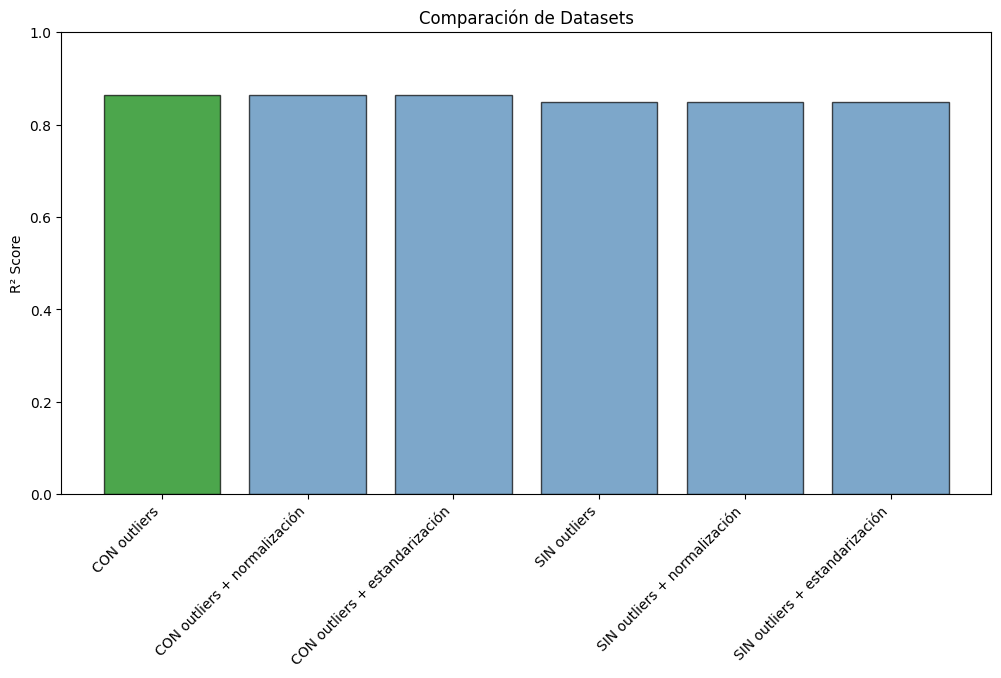

In [25]:
# Gráfico comparativo
plt.figure(figsize=(12, 6))
nombres = [d[2] for d in datasets]
colores = ['green' if i == best_index else 'steelblue' for i in range(len(datasets))]
plt.bar(range(len(nombres)), metrics, color=colores, edgecolor='black', alpha=0.7)
plt.xticks(range(len(nombres)), nombres, rotation=45, ha='right')
plt.ylabel('R² Score')
plt.title('Comparación de Datasets')
plt.ylim(0, 1)
plt.show()
plt.close()

# OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearch)

In [27]:
params_lasso = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    'max_iter': [1000, 5000, 10000]
}

print("\n Configuración de GridSearch:")
print(f"   Modelo: Lasso")
print(f"   Parámetros a probar: {len(params_lasso['alpha']) * len(params_lasso['max_iter'])} combinaciones")
print(f"   Alpha: {params_lasso['alpha']}")
print(f"   Max iterations: {params_lasso['max_iter']}")

# Grid Search 
grid = GridSearchCV(
    Lasso(random_state=42),
    params_lasso,
    scoring='r2',
    cv=5,  # Validación cruzada con 5 folds
    n_jobs=-1
)

grid.fit(best_X, best_y)

print(f"\n MEJORES HIPERPARÁMETROS ENCONTRADOS:")
for param, value in grid.best_params_.items():
    print(f"    {param}: {value}")

print(f"\n R² Score (validación cruzada): {grid.best_score_:.4f}")



 Configuración de GridSearch:
   Modelo: Lasso
   Parámetros a probar: 24 combinaciones
   Alpha: [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
   Max iterations: [1000, 5000, 10000]

 MEJORES HIPERPARÁMETROS ENCONTRADOS:
    alpha: 0.001
    max_iter: 1000

 R² Score (validación cruzada): 0.8629


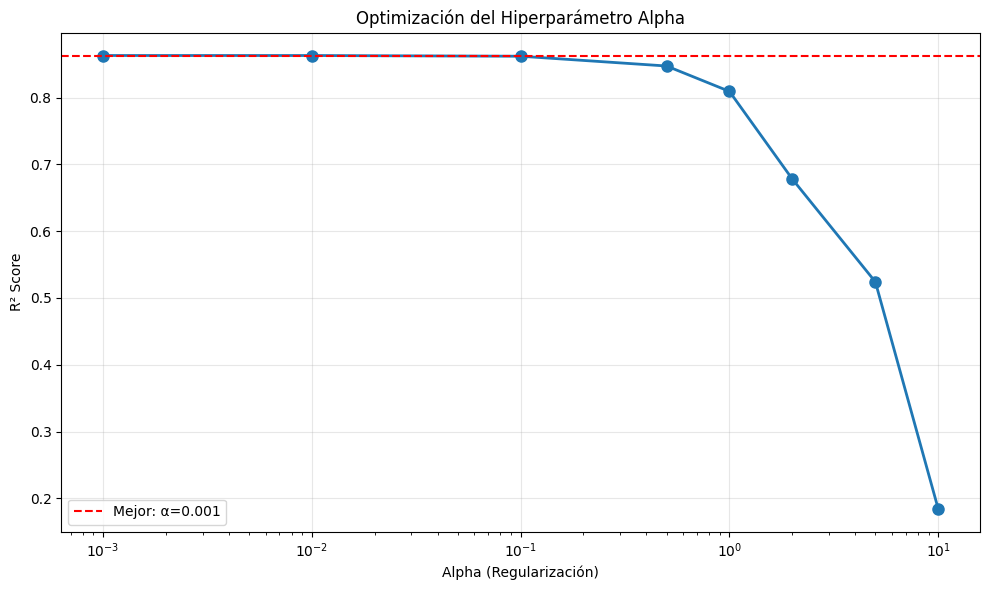

In [29]:
# Modelo optimizado
best_model = grid.best_estimator_

# Visualizar resultados del Grid Search
resultados_grid = pd.DataFrame(grid.cv_results_)
resultados_resumidos = resultados_grid.groupby('param_alpha')['mean_test_score'].max()

plt.figure(figsize=(10, 6))
plt.plot(resultados_resumidos.index.astype(float), resultados_resumidos.values, 
         marker='o', linewidth=2, markersize=8)
plt.xlabel('Alpha (Regularización)')
plt.ylabel('R² Score')
plt.title('Optimización del Hiperparámetro Alpha')
plt.xscale('log')
plt.grid(alpha=0.3)
plt.axhline(y=grid.best_score_, color='red', linestyle='--', 
            label=f'Mejor: α={grid.best_params_["alpha"]}')
plt.legend()
plt.tight_layout()
plt.show() 
plt.close()

# EVALUACIÓN FINAL EN TEST SET

In [30]:
if "normalización" in best_dataset_name:
    if "SIN outliers" in best_dataset_name:
        X_test_procesado = scaler_norm_sin.transform(X_test)
    else:
        X_test_procesado = scaler_norm.transform(X_test)
elif "estandarización" in best_dataset_name:
    if "SIN outliers" in best_dataset_name:
        X_test_procesado = scaler_scal_sin.transform(X_test)
    else:
        X_test_procesado = scaler_scal.transform(X_test)
else:
    X_test_procesado = X_test

In [32]:
# Predicciones
y_pred_train = best_model.predict(best_X)
y_pred_test = best_model.predict(X_test_procesado)

# Métricas finales
r2_train = r2_score(best_y, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(best_y, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_train = mean_absolute_error(best_y, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"\n RESULTADOS FINALES DEL MODELO OPTIMIZADO:")
print(f"\n   TRAIN SET:")
print(f"    R² Score: {r2_train:.4f}")
print(f"    RMSE: {rmse_train:.4f}")
print(f"    MAE: {mae_train:.4f}")
print(f"\n   TEST SET:")
print(f"    R² Score: {r2_test:.4f}")
print(f"    RMSE: {rmse_test:.4f}")
print(f"    MAE: {mae_test:.4f}")


 RESULTADOS FINALES DEL MODELO OPTIMIZADO:

   TRAIN SET:
    R² Score: 0.8638
    RMSE: 0.9944
    MAE: 0.7680

   TEST SET:
    R² Score: 0.8646
    RMSE: 1.0435
    MAE: 0.7792


In [33]:
# Coeficientes del modelo
coeficientes = pd.DataFrame({
    'Variable': features,
    'Coeficiente': best_model.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print(f"\n IMPORTANCIA DE LAS VARIABLES:")
for idx, row in coeficientes.iterrows():
    print(f"   • {row['Variable'][:45]:45s}: {row['Coeficiente']:7.4f}")


 IMPORTANCIA DE LAS VARIABLES:
   • Heart disease_prevalence                     :  0.7623
   • Unemployment_rate_2018                       :  0.1242
   • Obesity_prevalence                           :  0.1078
   • Percent of adults with less than a high schoo:  0.0968
   • PCTPOVALL_2018                               :  0.0812


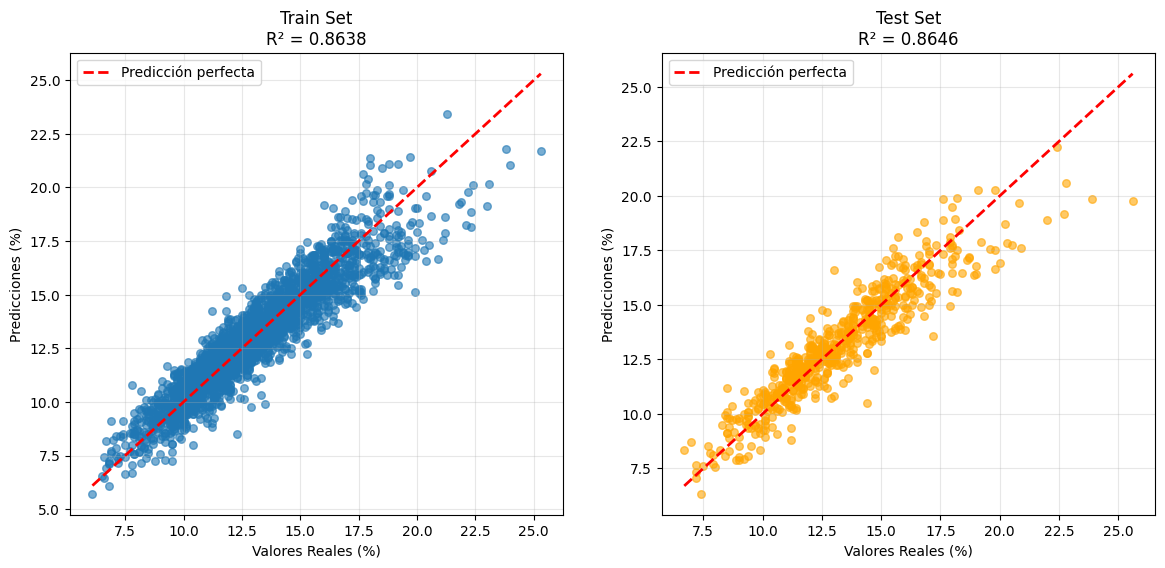

In [34]:
# Gráfico final: Predicciones vs Realidad
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Train
axes[0].scatter(best_y, y_pred_train, alpha=0.6, s=30)
axes[0].plot([best_y.min(), best_y.max()], [best_y.min(), best_y.max()], 
             'r--', lw=2, label='Predicción perfecta')
axes[0].set_xlabel('Valores Reales (%)')
axes[0].set_ylabel('Predicciones (%)')
axes[0].set_title(f'Train Set\nR² = {r2_train:.4f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Test
axes[1].scatter(y_test, y_pred_test, alpha=0.6, s=30, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Predicción perfecta')
axes[1].set_xlabel('Valores Reales (%)')
axes[1].set_ylabel('Predicciones (%)')
axes[1].set_title(f'Test Set\nR² = {r2_test:.4f}')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.show() 
plt.close()


# RESUMEN FINAL

## DATOS UTILIZADOS

Muestra: 3,140 condados de Estados Unidos
Período: 2018-2019
Variable objetivo: Prevalencia de diabetes (media: 13.07%)
Variables predictoras: 5 variables sociodemográficas y de salud
División: 80% entrenamiento (2,512) / 20% prueba (628)


## Calidad del Modelo:

R² superior a 0.85 indica ajuste de alta calidad
Error promedio inferior al 1% demuestra alta precisión
Ausencia de sobreajuste (train ≈ test) garantiza generalización
Validación cruzada confirma estabilidad del modelo

## CONGIGURACION TECNICA: 

Modelo: Lasso Regularizado
Alpha: 0.001
Max iterations: 1,000
Random state: 42
Validación: Cross-validation (5 folds)
Dataset: Con outliers (sin procesamiento)